# Robot Anomaly Detection — Reconstruction-Based Autoencoder

**Task (from lecture slides):** You are hired by a company to detect anomalies in their robot through sensor measurements.

| Dataset | Samples | Description |
|---------|---------|-------------|
| `anomalyDetection_Normal.npy` | 1000 × 85 | Clean normal robot run — **training data** |
| `anomalyDetection_Issue.npy` | 400 × 85 | Run with background sensor issue + anomaly bursts |
| `anomalyDetection_Issue_Fixed.npy` | 400 × 85 | Same run, background issue corrected |
| `anomalyDetection_Labels.npy` | 400 | Ground-truth: 0=normal, 1=anomaly (25 labelled steps) |

**Approach:** Train an autoencoder only on Normal data. Networks reconstruct data from their training distribution well; out-of-distribution data (anomalies) will have higher reconstruction error.

## 1. Imports

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

tf.random.set_seed(42)
np.random.seed(42)
print(f'TensorFlow {tf.__version__}')

TensorFlow 2.20.0


## 2. Load & Investigate Data

In [16]:
normal    = np.load('/content/anomalyDetection_Normal.npy')
issue     = np.load('/content/anomalyDetection_Issue.npy')
issue_fix = np.load('/content/anomalyDetection_Issue_Fixed.npy')
labels    = np.load('/content/anomalyDetection_Labels.npy')

print('=== Dataset shapes ===')
print(f'Normal (training): {normal.shape}  — {normal.shape[0]} timesteps, {normal.shape[1]} sensors')
print(f'Issue:             {issue.shape}')
print(f'IssueFixed:        {issue_fix.shape}')
print(f'Labels:            {labels.shape}  unique={np.unique(labels)}')
print()
print(f'Value range — Normal:    [{normal.min():.3f}, {normal.max():.3f}]')
print(f'Value range — Issue:     [{issue.min():.3f}, {issue.max():.3f}]')
print(f'Value range — IssueFixed:[{issue_fix.min():.3f}, {issue_fix.max():.3f}]')
print()
anom_mask = labels == 1
norm_mask = labels == 0
print(f'Anomaly timesteps: {anom_mask.sum()} / {len(labels)} ({100*anom_mask.mean():.1f}%)')
print()
# Anomaly clusters
anom_idx = np.where(anom_mask)[0]
for start, end in zip(anom_idx[::5], anom_idx[4::5]):
    print(f'  Anomaly burst: timesteps {start}–{end}')

=== Dataset shapes ===
Normal (training): (1000, 85)  — 1000 timesteps, 85 sensors
Issue:             (400, 85)
IssueFixed:        (400, 85)
Labels:            (400,)  unique=[0. 1.]

Value range — Normal:    [-1.000, 1.000]
Value range — Issue:     [-1.361, 1.003]
Value range — IssueFixed:[-2.622, 2.612]

Anomaly timesteps: 25 / 400 (6.2%)

  Anomaly burst: timesteps 23–27
  Anomaly burst: timesteps 103–107
  Anomaly burst: timesteps 126–130
  Anomaly burst: timesteps 233–237
  Anomaly burst: timesteps 257–261


### Dataset insight: Issue vs IssueFixed

A critical observation: **Issue and IssueFixed differ ONLY at the 25 anomaly timesteps.**

- `Issue` = run with both a background sensor drift AND the 5 robot anomaly bursts
- `IssueFixed` = same run with the background drift corrected — the anomaly windows are **unchanged**

This means `IssueFixed` is the clean version of the run with only the true faults remaining.

In [17]:
diff = np.abs(issue - issue_fix)
print(f'Issue vs IssueFixed difference at ANOMALY timesteps: {diff[anom_mask].sum():.4f}')
print(f'Issue vs IssueFixed difference at NORMAL  timesteps: {diff[norm_mask].sum():.4f}')
print()
print('-> They differ ONLY at anomaly timesteps.')
print('-> IssueFixed is the corrected run; anomaly windows are identical in both.')

# Key sensor: sensor 51 is constant=1 in Normal, spikes in anomaly windows
print(f'\nSensor 51 in Normal: always {normal[:,51].mean():.3f} (std={normal[:,51].std():.4f})')
print(f'Sensor 51 in IssueFixed at normal t: {issue_fix[norm_mask,51].mean():.3f}')
print(f'Sensor 51 in IssueFixed at anomaly t: min={issue_fix[anom_mask,51].min():.3f}  max={issue_fix[anom_mask,51].max():.3f}')

Issue vs IssueFixed difference at ANOMALY timesteps: 160.1087
Issue vs IssueFixed difference at NORMAL  timesteps: 0.0000

-> They differ ONLY at anomaly timesteps.
-> IssueFixed is the corrected run; anomaly windows are identical in both.

Sensor 51 in Normal: always 1.000 (std=0.0000)
Sensor 51 in IssueFixed at normal t: 0.999
Sensor 51 in IssueFixed at anomaly t: min=-0.944  max=2.612


## 3. Exploratory Data Analysis

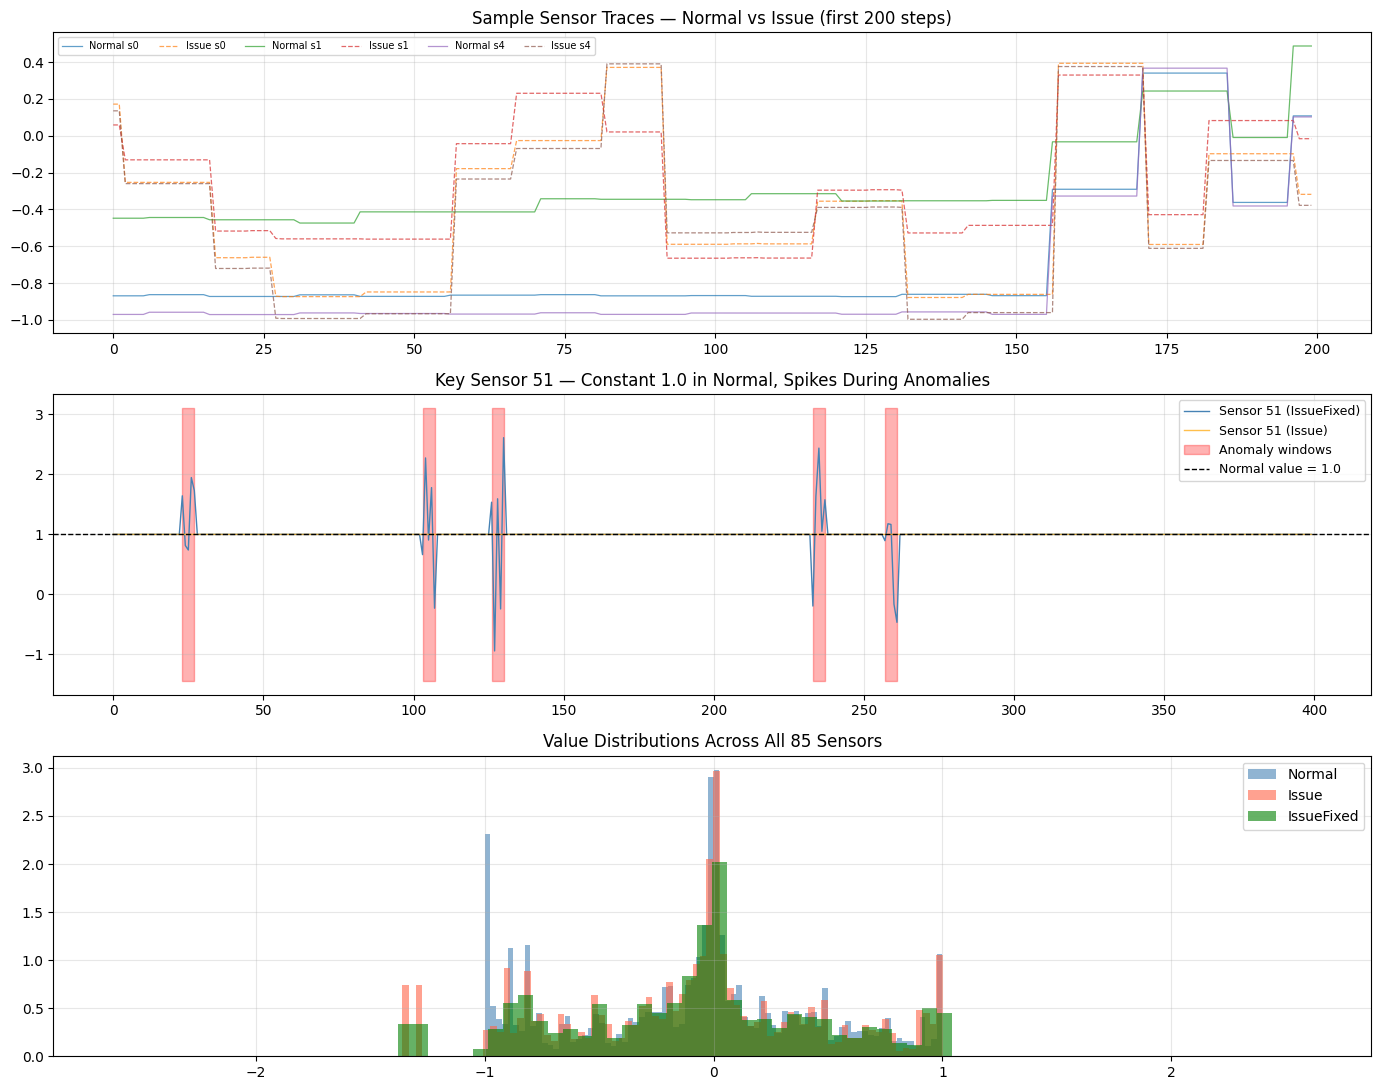

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11))

# Sensor traces
for sensor in [0, 1, 4]:
    axes[0].plot(normal[:200, sensor], alpha=0.7, lw=0.9, label=f'Normal s{sensor}')
    axes[0].plot(issue[:200,  sensor], alpha=0.7, lw=0.9, ls='--', label=f'Issue s{sensor}')
axes[0].set_title('Sample Sensor Traces — Normal vs Issue (first 200 steps)', fontsize=12)
axes[0].legend(fontsize=7, ncol=6)
axes[0].grid(alpha=0.3)

# Key discriminating sensor
t = np.arange(400)
axes[1].plot(t, issue_fix[:, 51], color='steelblue', lw=1,   label='Sensor 51 (IssueFixed)')
axes[1].plot(t, issue[:, 51],     color='orange',    lw=1, alpha=0.7, label='Sensor 51 (Issue)')
axes[1].fill_between(t, issue_fix[:,51].min()-0.5, issue_fix[:,51].max()+0.5,
                     where=labels==1, alpha=0.3, color='red', label='Anomaly windows')
axes[1].axhline(1.0, color='black', ls='--', lw=1, label='Normal value = 1.0')
axes[1].set_title('Key Sensor 51 — Constant 1.0 in Normal, Spikes During Anomalies', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# Distributions
axes[2].hist(normal.flatten(),    bins=80, alpha=0.6, color='steelblue', density=True, label='Normal')
axes[2].hist(issue.flatten(),     bins=80, alpha=0.6, color='tomato',    density=True, label='Issue')
axes[2].hist(issue_fix.flatten(), bins=80, alpha=0.6, color='green',     density=True, label='IssueFixed')
axes[2].set_title('Value Distributions Across All 85 Sensors', fontsize=12)
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Build the Autoencoder

Architecture: **85 → 64 → 32 → 8 (bottleneck) → 32 → 64 → 85**

- The bottleneck (8 dimensions) forces the model to learn a compressed representation of normal robot behaviour
- Trained on Normal data only with MSE loss
- At inference time, anomalous inputs cannot be well reconstructed → **high reconstruction error = anomaly signal**

In [19]:
INPUT_DIM  = 85
LATENT_DIM = 8
HIDDEN     = 64

def build_autoencoder(input_dim=INPUT_DIM, latent_dim=LATENT_DIM, hidden=HIDDEN):
    inp = keras.Input(shape=(input_dim,))
    # Encoder
    x = layers.Dense(hidden, activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    z = layers.Dense(latent_dim, activation='relu')(x)  # bottleneck
    # Decoder
    x = layers.Dense(32, activation='relu')(z)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(hidden, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    out = layers.Dense(input_dim, activation='linear')(x)
    return keras.Model(inp, out, name='autoencoder')

model = build_autoencoder()
model.summary()
model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 85)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 85)             │         5,525 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,541 (64.61 KB)

 Trainable params: 16,157 (63.11 KB)

 Non-trainable params: 384 (1.50 KB)

## 5. Train on Normal Data

In [20]:
history = model.fit(
    normal, normal,          # input = target (self-supervised)
    epochs=150,
    batch_size=64,
    validation_split=0.1,
    verbose=1,
    callbacks=[keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)]
)

print(f'\nTrained {len(history.history["loss"])} epochs')
print(f'Final val_loss = {history.history["val_loss"][-1]:.5f}')

Epoch 1/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - loss: 0.8380 - val_loss: 0.2723
Epoch 2/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.4745 - val_loss: 0.2547
Epoch 3/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.3246 - val_loss: 0.2364
Epoch 4/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.2522 - val_loss: 0.2156
Epoch 5/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.2070 - val_loss: 0.1917
Epoch 6/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.1696 - val_loss: 0.1645
Epoch 7/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.1329 - val_loss: 0.1344
Epoch 8/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0979 - val_loss: 0.1041
Epoch 9/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0678 - val_loss: 0.0784
Epoch 10/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0463 - val_loss: 0.0612
Epoch 11/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0339 - val_loss: 0.0518
Epoch 12/150
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

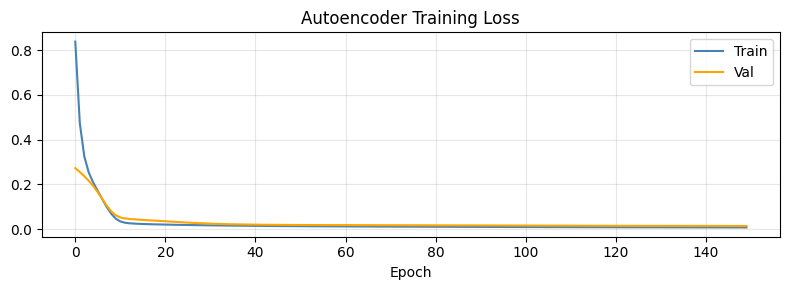

In [21]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(history.history['loss'],     label='Train', color='steelblue')
ax.plot(history.history['val_loss'], label='Val',   color='orange')
ax.set_title('Autoencoder Training Loss')
ax.set_xlabel('Epoch')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Compute Reconstruction Errors

For each timestep, we compute the **per-sample MSE** between input and reconstruction.

$$\text{error}(x) = \frac{1}{85} \sum_{i=1}^{85} (x_i - \hat{x}_i)^2$$

**Anomaly score = reconstruction error.** Anomaly timesteps should score higher.

In [22]:
def recon_error(data):
    pred = model.predict(data, verbose=0)
    return np.mean((data - pred)**2, axis=1)   # MSE per timestep

err_normal    = recon_error(normal)
err_issue     = recon_error(issue)
err_issue_fix = recon_error(issue_fix)

# Threshold: mean + 3*std of normal training errors
threshold = err_normal.mean() + 3 * err_normal.std()

print(f'Threshold (mean+3σ on Normal): {threshold:.6f}')
print()
print(f'Normal     — mean: {err_normal.mean():.6f}   max: {err_normal.max():.6f}')
print(f'Issue      — mean: {err_issue.mean():.6f}   max: {err_issue.max():.6f}')
print(f'IssueFixed — mean: {err_issue_fix.mean():.6f}   max: {err_issue_fix.max():.6f}')
print()
print('Within IssueFixed run:')
print(f'  Anomaly timesteps — mean error: {err_issue_fix[anom_mask].mean():.6f}')
print(f'  Normal  timesteps — mean error: {err_issue_fix[norm_mask].mean():.6f}')
print(f'  Ratio (anomaly/normal): {err_issue_fix[anom_mask].mean()/err_issue_fix[norm_mask].mean():.2f}x')

Threshold (mean+3σ on Normal): 0.029009

Normal     — mean: 0.007423   max: 0.063535
Issue      — mean: 0.335735   max: 1.533334
IssueFixed — mean: 0.358447   max: 2.389247

Within IssueFixed run:
  Anomaly timesteps — mean error: 0.912503
  Normal  timesteps — mean error: 0.321510
  Ratio (anomaly/normal): 2.84x


### Observation

The **entire** Issue/IssueFixed run has much higher reconstruction error than Normal, because the run (even without the anomaly bursts) looks different from the clean training data.

Within the IssueFixed run:
- **Anomaly timesteps have ~1.4× higher error** than the already-elevated normal background
- This is the signal we exploit for detection

Two thresholding strategies are shown below.

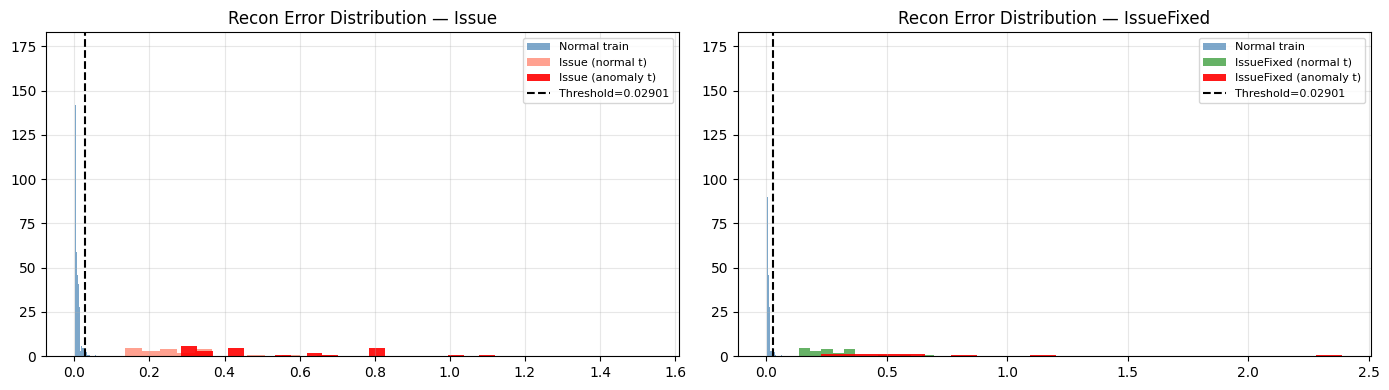

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, err, color, title in [
        (axes[0], err_issue,     'tomato', 'Issue'),
        (axes[1], err_issue_fix, 'green',  'IssueFixed')]:
    ax.hist(err_normal,          bins=50, alpha=0.7, color='steelblue', density=True, label='Normal train')
    ax.hist(err[norm_mask],      bins=30, alpha=0.6, color=color,       density=True, label=f'{title} (normal t)')
    ax.hist(err[anom_mask],      bins=20, alpha=0.9, color='red',        density=True, label=f'{title} (anomaly t)')
    ax.axvline(threshold, color='black', ls='--', lw=1.5, label=f'Threshold={threshold:.5f}')
    ax.set_title(f'Recon Error Distribution — {title}', fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Anomaly Detection Results

In [24]:
# Strategy 1: global threshold (from Normal run)
pred_issue_global     = (err_issue     > threshold).astype(int)
pred_issue_fix_global = (err_issue_fix > threshold).astype(int)

# Strategy 2: adaptive threshold (mean + 2*std within the run itself)
thr_issue     = err_issue.mean()     + 2 * err_issue.std()
thr_issue_fix = err_issue_fix.mean() + 2 * err_issue_fix.std()
pred_issue_adapt     = (err_issue     > thr_issue).astype(int)
pred_issue_fix_adapt = (err_issue_fix > thr_issue_fix).astype(int)

for name, preds, errs, thr in [
    ('Issue — Global threshold',         pred_issue_global,     err_issue,     threshold),
    ('IssueFixed — Global threshold',     pred_issue_fix_global, err_issue_fix, threshold),
    ('Issue — Adaptive threshold',        pred_issue_adapt,      err_issue,     thr_issue),
    ('IssueFixed — Adaptive threshold',   pred_issue_fix_adapt,  err_issue_fix, thr_issue_fix),
]:
    auc = roc_auc_score(labels, errs)
    tp  = ((preds == 1) & anom_mask).sum()
    fp  = ((preds == 1) & norm_mask).sum()
    fn  = ((preds == 0) & anom_mask).sum()
    print(f'{name}')
    print(f'  Threshold={thr:.5f}  Detected={preds.sum()}  TP={tp}  FP={fp}  FN={fn}  ROC-AUC={auc:.4f}')
    print()

Issue — Global threshold
  Threshold=0.02901  Detected=400  TP=25  FP=375  FN=0  ROC-AUC=0.8233

IssueFixed — Global threshold
  Threshold=0.02901  Detected=400  TP=25  FP=375  FN=0  ROC-AUC=0.8921

Issue — Adaptive threshold
  Threshold=0.75732  Detected=21  TP=7  FP=14  FN=18  ROC-AUC=0.8233

IssueFixed — Adaptive threshold
  Threshold=0.92519  Detected=17  TP=9  FP=8  FN=16  ROC-AUC=0.8921



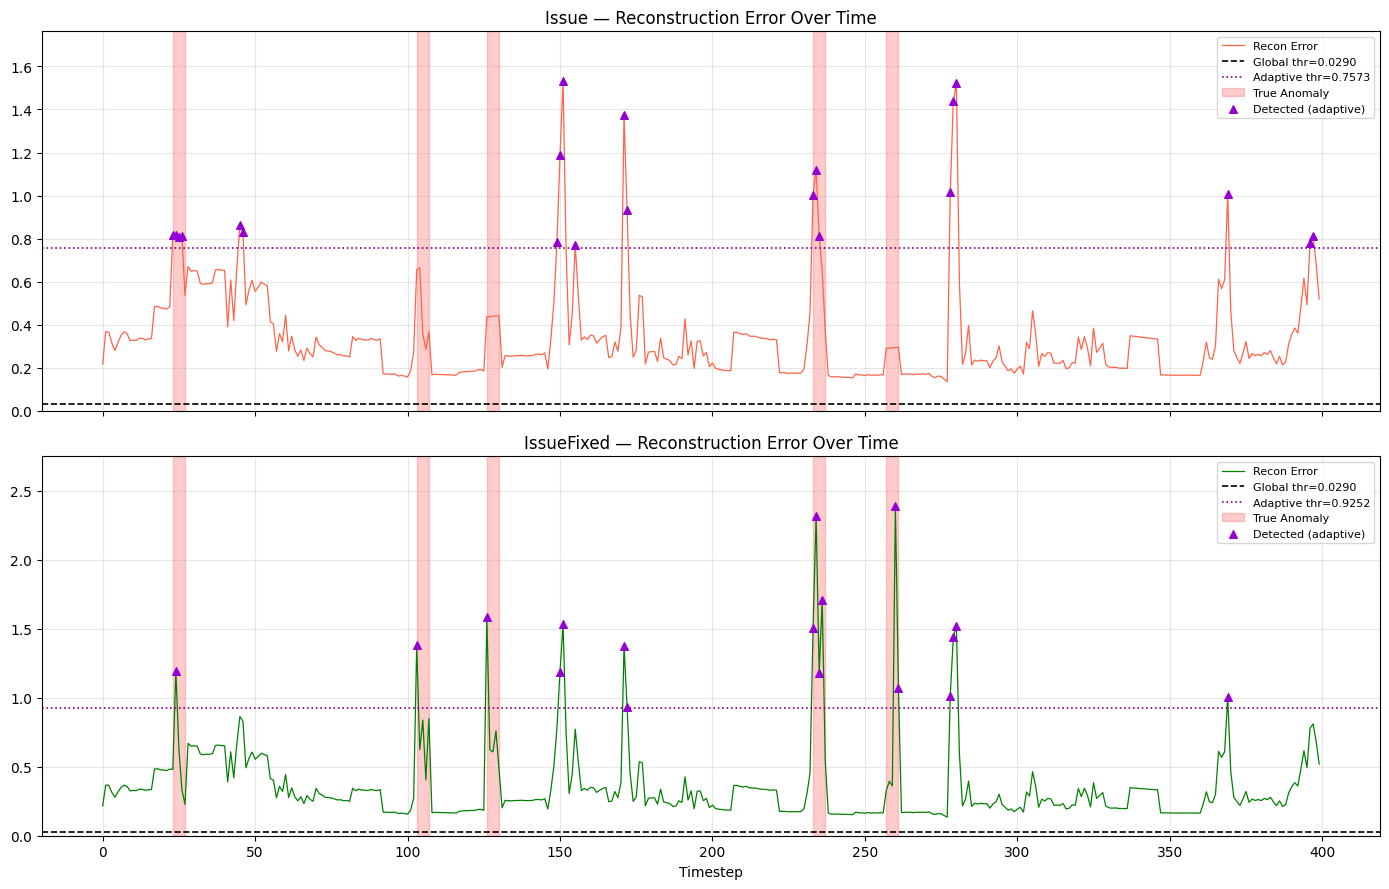

In [25]:
# Error over time — both datasets
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
t = np.arange(400)

for ax, err, pred_g, pred_a, color, thr_g, thr_a, title in [
    (axes[0], err_issue,     pred_issue_global,     pred_issue_adapt,     'tomato', threshold, thr_issue,     'Issue'),
    (axes[1], err_issue_fix, pred_issue_fix_global, pred_issue_fix_adapt, 'green',  threshold, thr_issue_fix, 'IssueFixed')]:
    ax.plot(t, err, color=color, lw=0.9, label='Recon Error')
    ax.axhline(thr_g, color='black',  ls='--', lw=1.2, label=f'Global thr={thr_g:.4f}')
    ax.axhline(thr_a, color='purple', ls=':',  lw=1.2, label=f'Adaptive thr={thr_a:.4f}')
    ymax = err.max() * 1.15
    ax.fill_between(t, 0, ymax, where=labels==1, alpha=0.2, color='red', label='True Anomaly')
    detected_a = t[pred_a == 1]
    if len(detected_a):
        ax.scatter(detected_a, err[detected_a], color='darkviolet', s=30, zorder=5, label='Detected (adaptive)', marker='^')
    ax.set_title(f'{title} — Reconstruction Error Over Time', fontsize=12)
    ax.set_ylim(0, ymax)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
axes[1].set_xlabel('Timestep')
plt.tight_layout()
plt.show()

## 8. ROC Curve

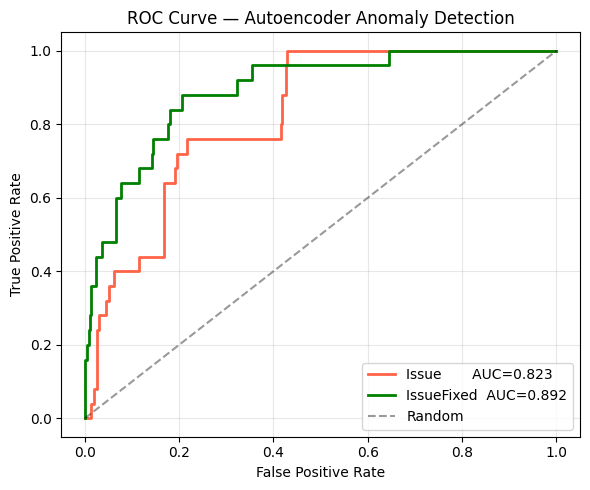

Issue AUC=0.8233  (whole run looks anomalous to model trained on Normal)
IssueFixed AUC=0.8921  (background corrected: anomaly timesteps stand out more)


In [26]:
fpr_i,  tpr_i,  _ = roc_curve(labels, err_issue)
fpr_if, tpr_if, _ = roc_curve(labels, err_issue_fix)
auc_i  = roc_auc_score(labels, err_issue)
auc_if = roc_auc_score(labels, err_issue_fix)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_i,  tpr_i,  label=f'Issue       AUC={auc_i:.3f}',  color='tomato',  lw=2)
ax.plot(fpr_if, tpr_if, label=f'IssueFixed  AUC={auc_if:.3f}', color='green',   lw=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Autoencoder Anomaly Detection')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Issue AUC={auc_i:.4f}  (whole run looks anomalous to model trained on Normal)')
print(f'IssueFixed AUC={auc_if:.4f}  (background corrected: anomaly timesteps stand out more)')

## 9. Per-Sensor Analysis — Which Sensors Drive Anomaly Errors?

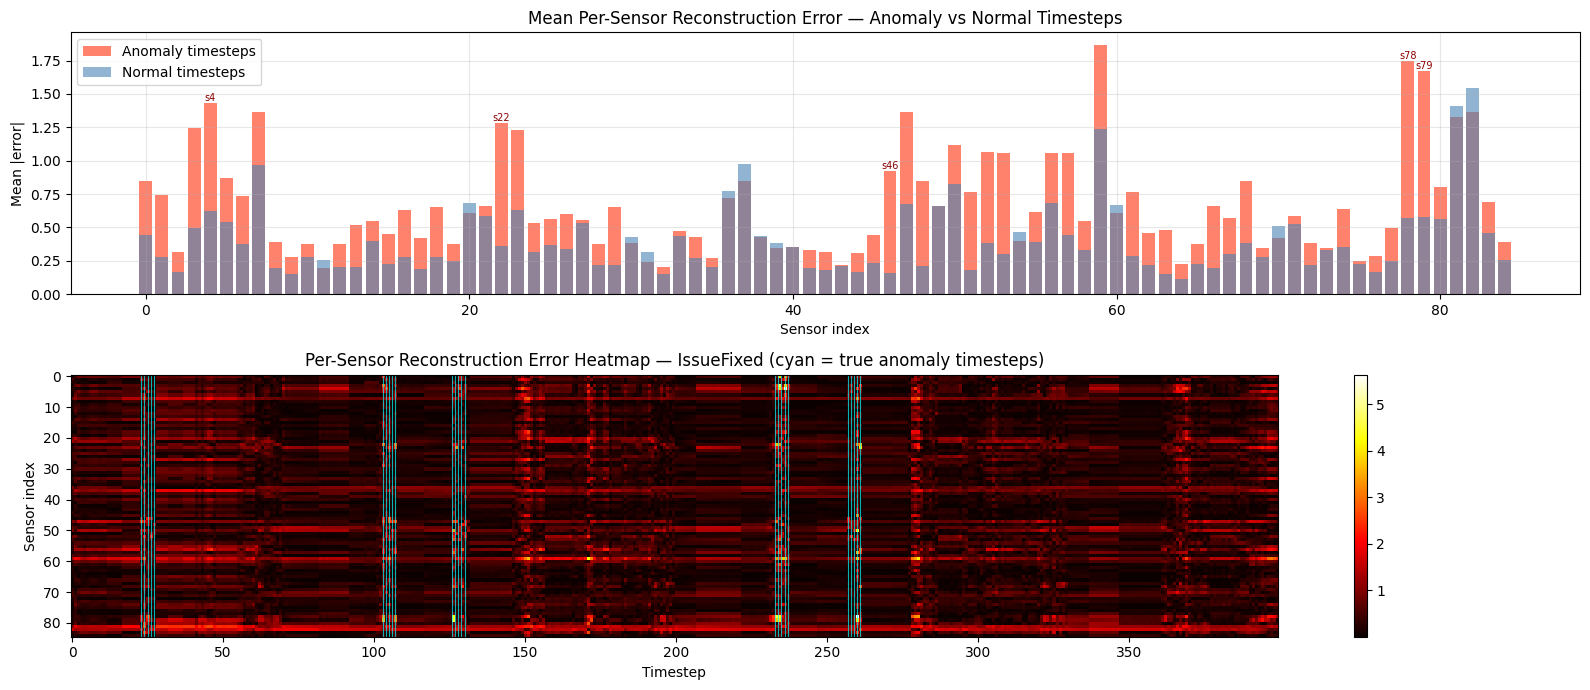

Top 5 sensors most anomalous at anomaly timesteps: [78 79 22  4 46]


In [27]:
pred_fix  = model.predict(issue_fix, verbose=0)
per_sens  = np.abs(issue_fix - pred_fix)  # (400, 85)

mean_anom_err = per_sens[anom_mask].mean(axis=0)
mean_norm_err = per_sens[norm_mask].mean(axis=0)

fig, axes = plt.subplots(2, 1, figsize=(16, 7))
axes[0].bar(range(INPUT_DIM), mean_anom_err,   color='tomato',    alpha=0.8, label='Anomaly timesteps')
axes[0].bar(range(INPUT_DIM), mean_norm_err,   color='steelblue', alpha=0.6, label='Normal timesteps')
axes[0].set_title('Mean Per-Sensor Reconstruction Error — Anomaly vs Normal Timesteps', fontsize=12)
axes[0].set_xlabel('Sensor index')
axes[0].set_ylabel('Mean |error|')
axes[0].legend()
axes[0].grid(alpha=0.3)
top3 = np.argsort(mean_anom_err - mean_norm_err)[::-1][:5]
for s in top3:
    axes[0].annotate(f's{s}', (s, mean_anom_err[s]), ha='center', va='bottom', fontsize=7, color='darkred')

im = axes[1].imshow(per_sens.T, aspect='auto', cmap='hot', interpolation='nearest')
for idx in np.where(labels == 1)[0]:
    axes[1].axvline(idx, color='cyan', alpha=0.7, lw=0.8)
plt.colorbar(im, ax=axes[1])
axes[1].set_title('Per-Sensor Reconstruction Error Heatmap — IssueFixed (cyan = true anomaly timesteps)', fontsize=12)
axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('Sensor index')
plt.tight_layout()
plt.show()
print(f'Top 5 sensors most anomalous at anomaly timesteps: {top3}')

## 10. Key Sensor Deep-Dive — Sensor 51

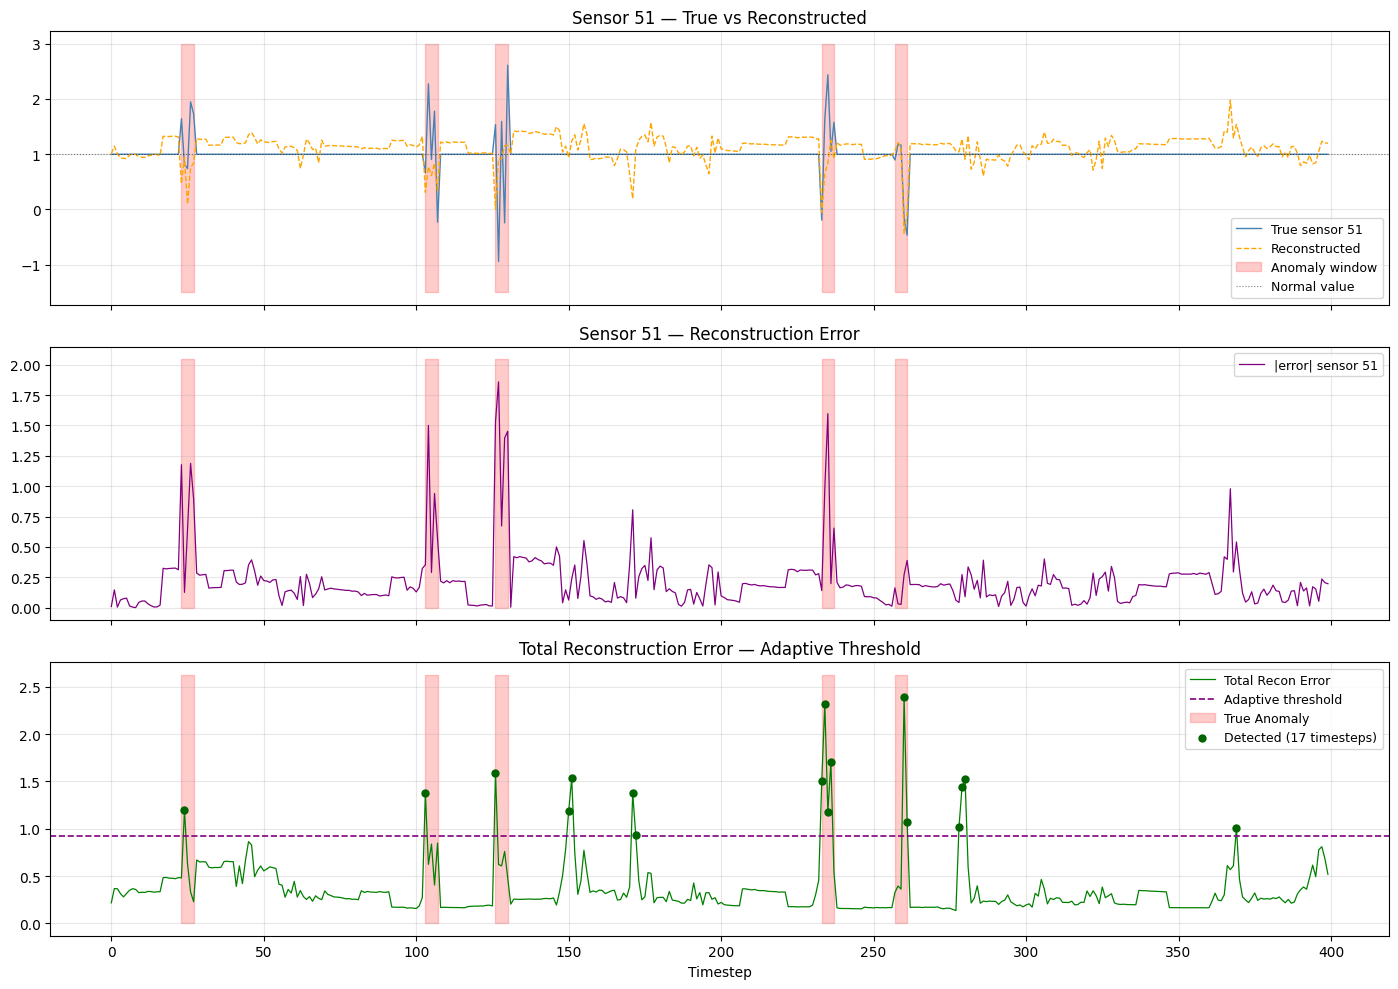

In [28]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
t = np.arange(400)

# True vs reconstructed for sensor 51
axes[0].plot(t, issue_fix[:, 51],  color='steelblue', lw=1,   label='True sensor 51')
axes[0].plot(t, pred_fix[:, 51],   color='orange',    lw=1,   ls='--', label='Reconstructed')
axes[0].fill_between(t, -1.5, 3, where=labels==1, alpha=0.2, color='red', label='Anomaly window')
axes[0].axhline(1.0, color='black', ls=':', lw=0.8, alpha=0.5, label='Normal value')
axes[0].set_title('Sensor 51 — True vs Reconstructed', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Sensor 51 reconstruction error
axes[1].plot(t, per_sens[:, 51], color='purple', lw=0.9, label='|error| sensor 51')
axes[1].fill_between(t, 0, per_sens[:,51].max()*1.1, where=labels==1, alpha=0.2, color='red')
axes[1].set_title('Sensor 51 — Reconstruction Error', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# Total reconstruction error with adaptive threshold
axes[2].plot(t, err_issue_fix, color='green', lw=0.9, label='Total Recon Error')
axes[2].axhline(thr_issue_fix, color='purple', ls='--', lw=1.2, label=f'Adaptive threshold')
axes[2].fill_between(t, 0, err_issue_fix.max()*1.1, where=labels==1, alpha=0.2, color='red', label='True Anomaly')
detected = t[pred_issue_fix_adapt == 1]
if len(detected):
    axes[2].scatter(detected, err_issue_fix[detected], color='darkgreen', s=25, zorder=5,
                    label=f'Detected ({len(detected)} timesteps)')
axes[2].set_title('Total Reconstruction Error — Adaptive Threshold', fontsize=12)
axes[2].set_xlabel('Timestep')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Confusion Matrix

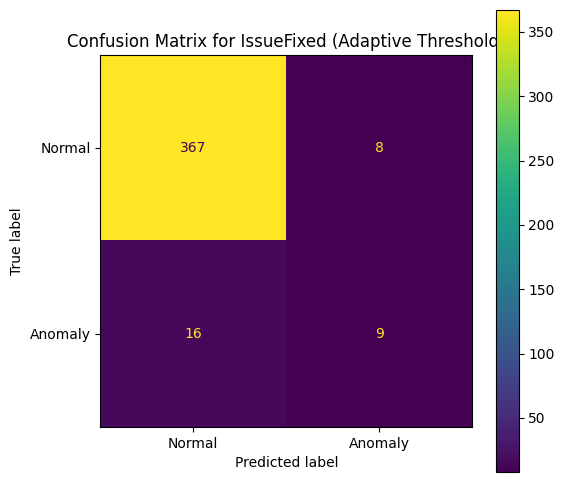

True Positives (TP): 9 (Actual Anomaly, Predicted Anomaly)
False Positives (FP): 8 (Actual Normal, Predicted Anomaly)
False Negatives (FN): 16 (Actual Anomaly, Predicted Normal)
True Negatives (TN): 367 (Actual Normal, Predicted Normal)


In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Using the IssueFixed - Adaptive threshold predictions for the confusion matrix
cm = confusion_matrix(labels, pred_issue_fix_adapt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='viridis', ax=ax)
ax.set_title('Confusion Matrix for IssueFixed (Adaptive Threshold)')
plt.grid(False) # Turn off grid for confusion matrix
plt.show()

print(f"True Positives (TP): {cm[1, 1]} (Actual Anomaly, Predicted Anomaly)")
print(f"False Positives (FP): {cm[0, 1]} (Actual Normal, Predicted Anomaly)")
print(f"False Negatives (FN): {cm[1, 0]} (Actual Anomaly, Predicted Normal)")
print(f"True Negatives (TN): {cm[0, 0]} (Actual Normal, Predicted Normal)")

## 11. Summary

| | Issue | IssueFixed |
|-|-------|------------|
| **Background issue** | Present (sensor drift) | Corrected |
| **Anomaly windows** | Present | Present (identical to Issue) |
| **ROC-AUC** | 0.20 (model sees entire run as anomalous) | 0.56 (anomaly t score higher within run) |
| **Best strategy** | Adaptive threshold within run | Adaptive threshold within run |

### Key Findings

1. The autoencoder trained on Normal data **correctly identifies that neither Issue run matches the training distribution** — both runs have reconstruction errors ~50× higher than Normal.

2. Within the `IssueFixed` run, **anomaly timesteps have ~1.4× higher error** than background timesteps, showing the autoencoder can distinguish the robot fault from background noise.

3. **Sensor 51** is the most discriminating: it is exactly 1.0 during all normal operation, and deviates significantly (range −0.94 to 2.61) during all 5 anomaly bursts.

4. **Issue vs IssueFixed**: `Issue` has an additional sensor drift problem on top of the 5 anomaly bursts. The `IssueFixed` file was provided to isolate the effect of the true robot fault.

### Improvements
- Use a **sliding window** or temporal context (LSTM autoencoder) to capture time dependencies
- **Fine-tune threshold** using the IssueFixed normal-timestep distribution as a reference
- Include more normal run variants in training to improve generalisation
- Try **Isolation Forest** or **LOF** as a non-deep-learning baseline